In [1]:
from homicsx.core import(
    GeometryInput,
    PhysicalTags,
    MeshSettings,
    MaterialAssignment,
    LinearElasticIsotropic,
    ProblemSettings,
)
from homicsx.utils import extract_effective_moduli_3d
from homicsx.geometry import patriculate_geometry_generator
from homicsx.mesh import generate_mesh
from homicsx.stochastic import perform_ensemble_study
from homicsx import solve_linear_homogenization

import numpy as np
import matplotlib.pyplot as plt
from statistics import mean

Setting up the neccessary inputs/settings (except for geometry input object which will be generated in the convergence loop)

In [2]:
mesh_settings = MeshSettings(
    min_size=0.02,
    max_size=0.03,
)

E_mat = 1.0
nu_mat = 0.3
mat_matrix = LinearElasticIsotropic(young_modulus=E_mat, poisson_ratio=nu_mat)

E_inc = 100.0
nu_inc = 0.3
mat_particle = LinearElasticIsotropic(young_modulus=E_inc, poisson_ratio=nu_inc)

material_assignment = MaterialAssignment(
    materials_by_phase={
        0: mat_matrix,
        1: mat_particle,
    }
)

fem_settings = ProblemSettings(
    dim=2,
    kinematics='small_strain',
    two_dimensional_formulation='plane_strain',
    element_family='Lagrange',
    element_degree=1,
)

Running the convergence loop

In [3]:
num_particles_list = np.linspace(1, 80, 40)

E_mean_list = []
for num_particles in num_particles_list:
    geometry_settings = GeometryInput(
        dim=2,
        dispersion='mono',
        volume_fraction=0.2,
        num_particles=int(num_particles),
        clearance=0.015,
        domain_size=(1, 1),
        shape='circle',
    )

    result = perform_ensemble_study(
        ensemble_size=3,
        geometry_input=geometry_settings,
        mesh_settings=mesh_settings,
        Physical_tags=PhysicalTags(),
        assignment=material_assignment,
        fem_settings=fem_settings,
        matrix_phase_id=0,
        homogenization_solver='linear',
        homogenization_mode='partial',
    )

    E_mean = result.result_summary.engineering_moduli_mean['E']
    E_mean_list.append(E_mean)

Post-processing

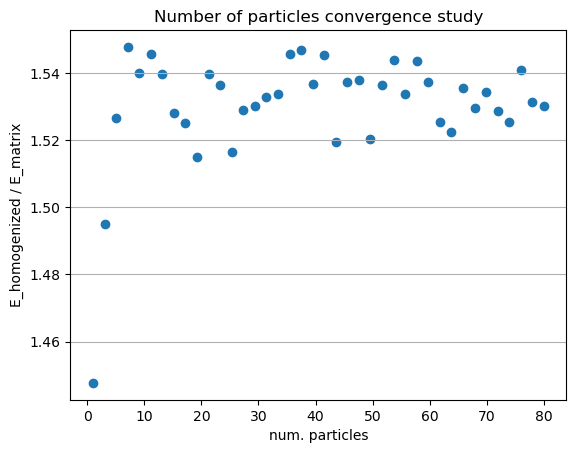

In [4]:
plt.scatter(num_particles_list, E_mean_list, marker='o')
plt.title('Number of particles convergence study')
plt.xlabel('num. particles')
plt.ylabel('E_homogenized / E_matrix')
plt.grid(visible=True, which='major', axis='y')
plt.show()